In [ ]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import RocCurveDisplay

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

import os
df = pd.read_csv("../data/irrigation_prediction.csv")
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv


# Load Dataset

In [ ]:
df = pd.read_csv("/kaggle/input/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv")
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


# Dataset Info & Summary

In [ ]:
# Dataset info
df.info()

# Summary statistics for numerical columns
df.describe()

# Check missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  object 
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  object 
 11  Crop_Growth_Stage        10000 non-null  object 
 12  Season                   10000 non-null  object 
 13  Irrigation_Type          10000 non-null  object 
 14  Water_Source           

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

# Separate Categorical & Numerical Columns

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)


Categorical Columns: Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region',
       'Irrigation_Need'],
      dtype='object')
Numerical Columns: Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'],
      dtype='object')


# Exploratory Data Analysis (EDA) - Numerical Columns

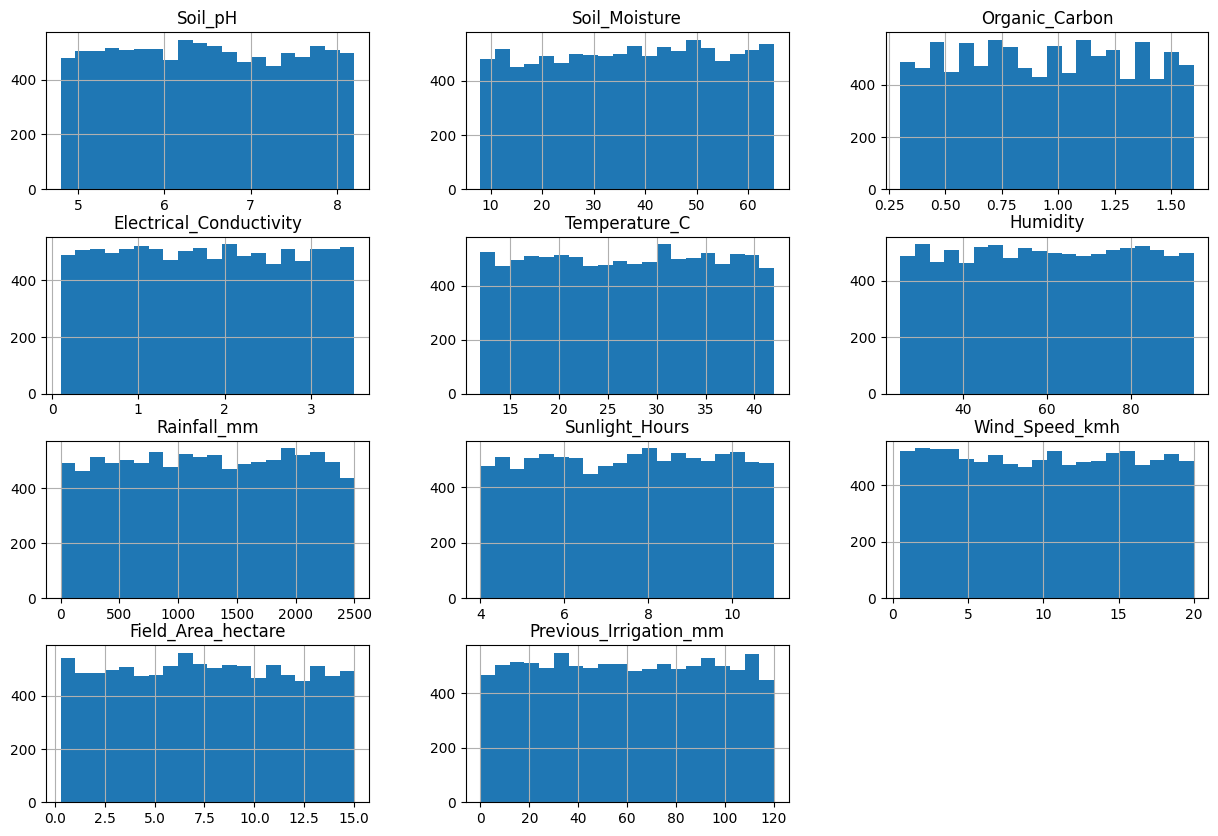

In [ ]:
# Histograms
df[numerical_cols].hist(figsize=(15,10), bins=20)
plt.show()

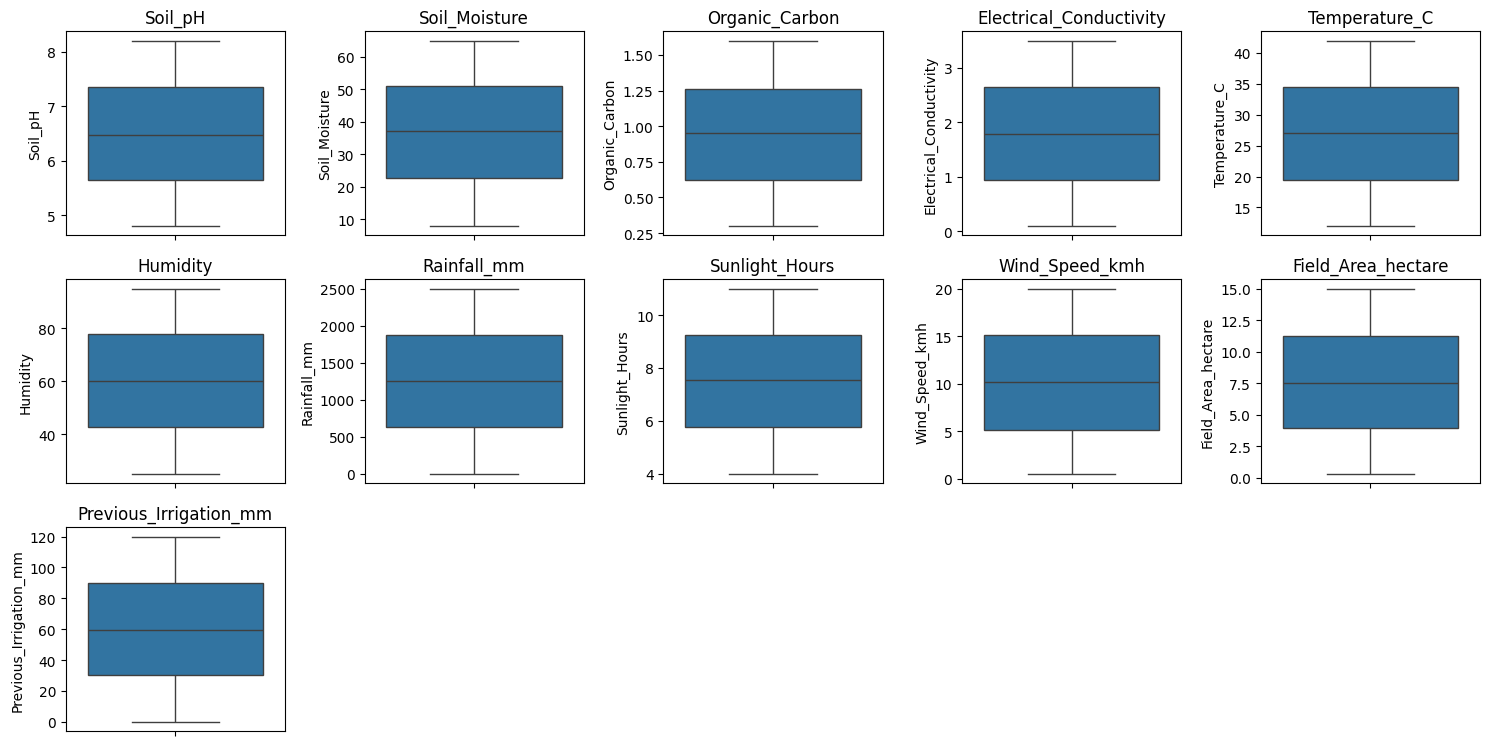

In [ ]:
# Boxplots
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,5,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


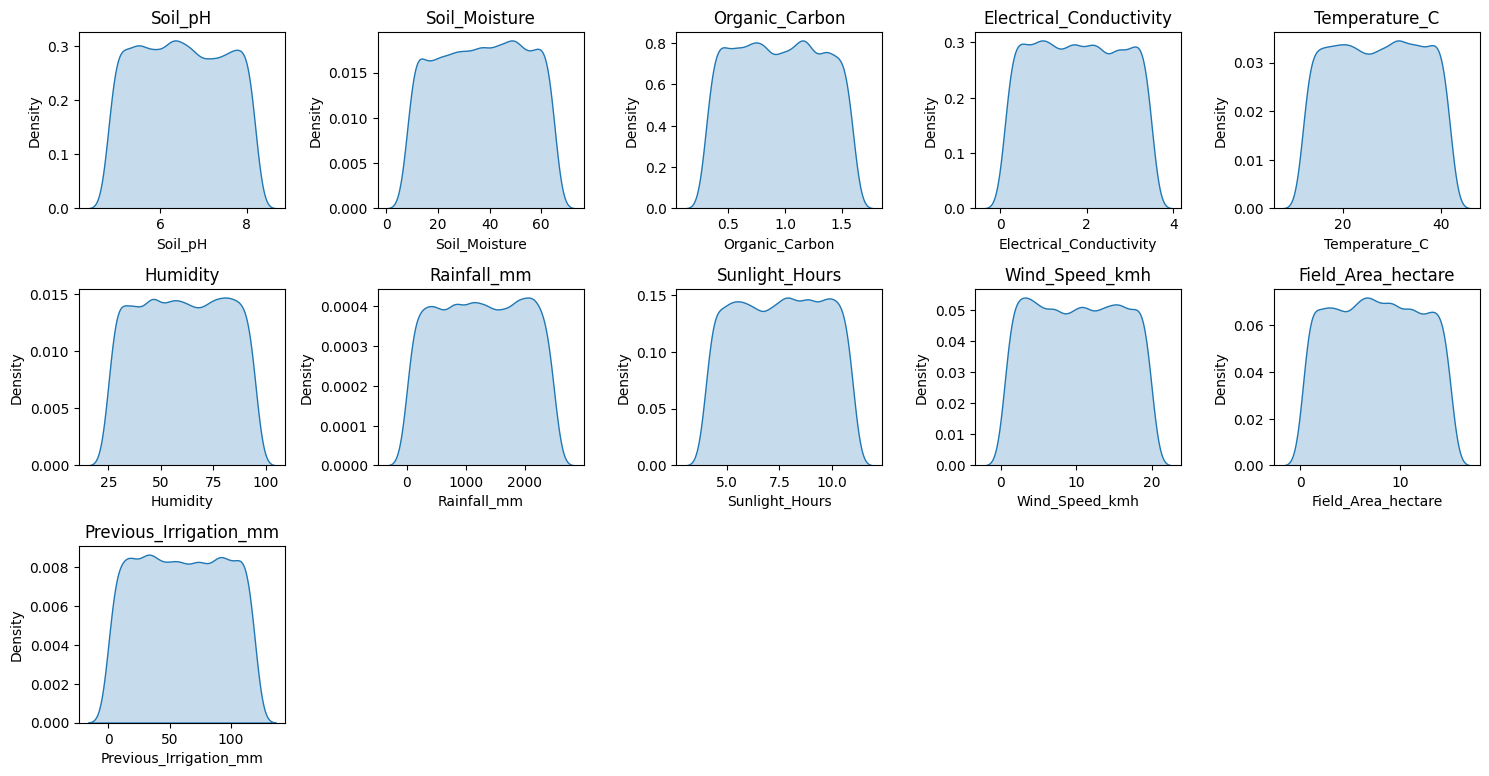

In [ ]:
# KDE Plots
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,5,i+1)
    sns.kdeplot(df[col], shade=True)
    plt.title(col)
plt.tight_layout()
plt.show()

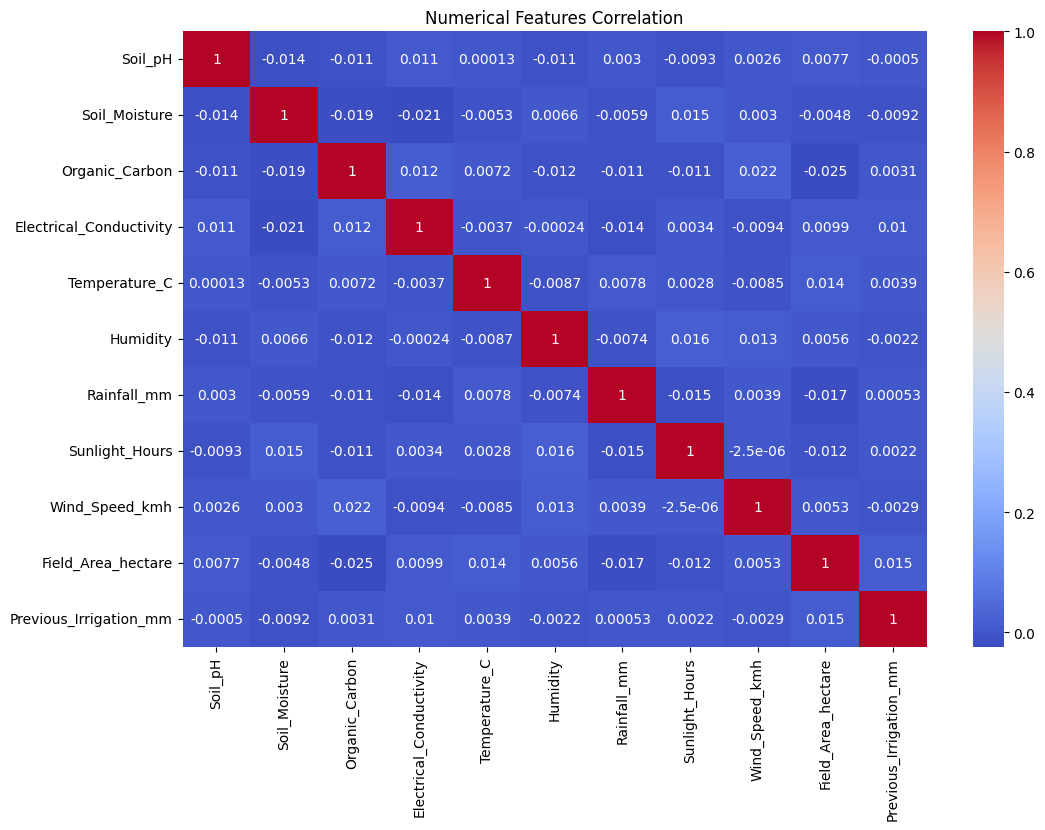

In [ ]:
# Heatmap for correlation
plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Numerical Features Correlation")
plt.show()

# EDA - Categorical Columns

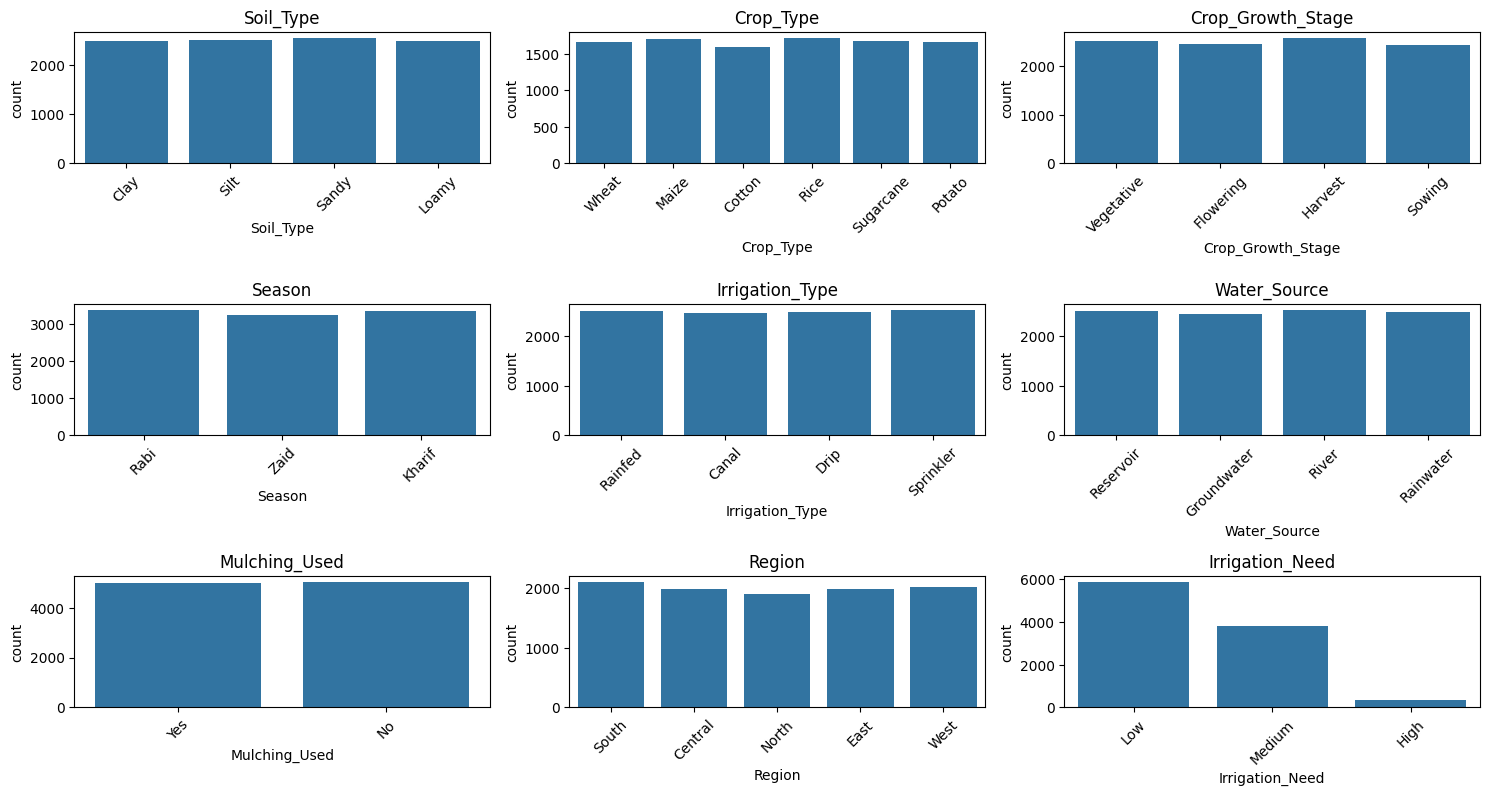

In [ ]:
# Countplots / Barplots
plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(4,3,i+1)
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()


# Pie Charts for Categorical Columns

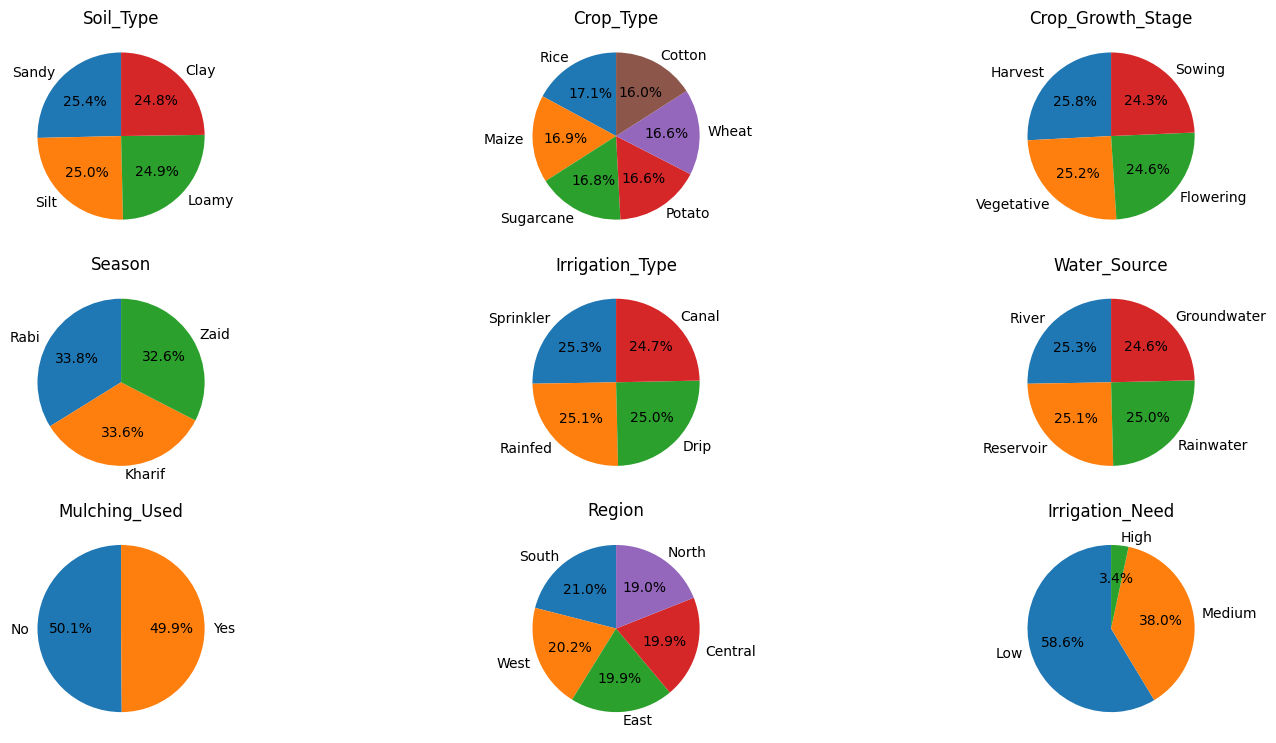

In [ ]:
plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(4,3,i+1)
    df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(col)
    plt.ylabel('')
plt.tight_layout()
plt.show()


# Encode Categorical Columns & Scale Numerical Columns

In [ ]:
# Label Encoding for categorical columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# MinMax Scaling for numerical columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df.head()


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,0.394118,0.499649,0.092308,0.608824,0.330000,0.088429,0.467057,0.001429,0.075385,5,3,1,2,2,0.301361,1,0.016337,3,1
1,3,0.473529,0.746667,0.061538,0.038235,0.816667,0.014429,0.332452,0.960000,0.836923,1,0,2,0,0,0.810884,1,0.279570,0,2
2,2,0.855882,0.562632,0.607692,0.611765,0.994333,0.734429,0.737832,0.535714,0.950256,0,1,1,1,2,0.355102,1,0.288405,3,1
3,0,0.341176,0.083333,0.969231,0.088235,0.840667,0.261714,0.122386,0.700000,0.561026,5,2,0,0,2,0.076871,1,0.700258,2,2
4,0,0.870588,0.185614,0.500000,0.711765,0.346000,0.877714,0.750307,0.912857,0.551795,0,2,2,0,3,0.151020,0,0.507127,3,2


# Train-Test Split

In [ ]:
X = df.drop("Irrigation_Need", axis=1)
y = df["Irrigation_Need"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (8000, 19)
Test Shape: (2000, 19)


# Build 10 Classification Models & Evaluate

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-"*50)


Logistic Regression Accuracy: 0.7225
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.22      0.34        67
           1       0.77      0.83      0.80      1173
           2       0.65      0.60      0.62       760

    accuracy                           0.72      2000
   macro avg       0.71      0.55      0.59      2000
weighted avg       0.72      0.72      0.72      2000

Confusion Matrix:
[[ 15   1  51]
 [  0 972 201]
 [  6 296 458]]
--------------------------------------------------
Decision Tree Accuracy: 0.9960
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        67
           1       1.00      1.00      1.00      1173
           2       0.99      0.99      0.99       760

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Confusion

# Feature Importance (For Tree-based Models)

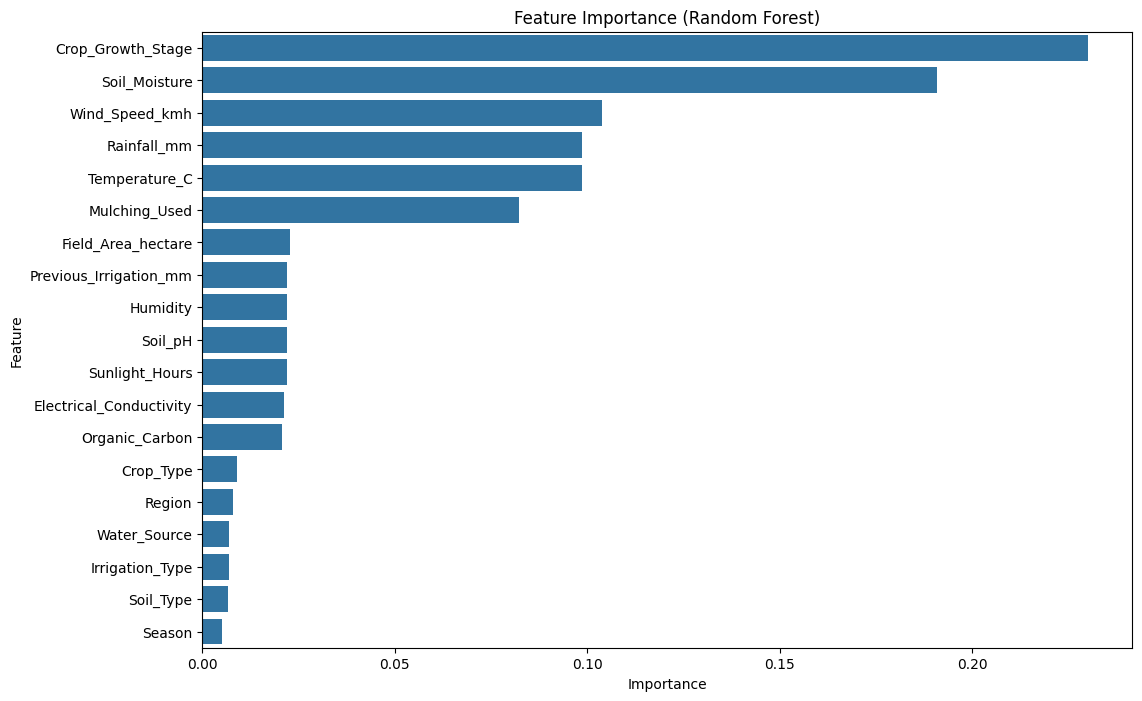

In [ ]:
# Using Random Forest as example
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title("Feature Importance (Random Forest)")
plt.show()
